In [ ]:
# read final_df
import pandas as pd
df_final = pd.read_csv(r'd:/Github/Data/final_material_data_20250114.csv')
# exclude historical buildings before 1930
df_final_wt_hb = df_final[df_final['year of construction of the building yyyy'] >= 1930]
# # exclude buildings newer than 2020
# df_final_wt_hb = df_final_wt_hb[df_final_wt_hb['year of construction of the building yyyy'] <= 2020]
# remove bathtubs for all buildings except residential buildings
df_final_wt_hb = df_final_wt_hb[~((df_final_wt_hb['component'] == 'bathtub') & (df_final_wt_hb['building class'] != 'residential'))]
# add stainless steel and steel to be the same material
df_final_wt_hb['material'] = df_final_wt_hb['material'].replace({'stainless steel': 'steel'})
# Define component lifespan
component_lifespan = {
    'electrical cable': 50,
    'boiler': 35,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 35,
    'heat pump': 30,
    'toilet': 50,
    'shower': 30,
    'sink': 50,
    'bathtub': 50
}

# Add end-of-life year for each component
df_final_wt_hb['end_of_life_year'] = df_final_wt_hb['year of construction of the building yyyy'] + df_final_wt_hb['component'].map(component_lifespan)

# Group by decade of end-of-life year and material type, summing material weights
df_final_wt_hb['end_of_life_decade'] = (df_final_wt_hb['end_of_life_year'] // 10) * 10
material_availability = df_final_wt_hb.groupby(['end_of_life_decade', 'material'])['material_weight'].sum().unstack(fill_value=0)

In [ ]:
from SALib.sample import latin
import pandas as pd

# 组件属性表格（你提供的简化字段）
components = pd.DataFrame([
    ['Electrical Cable', 5, 5, 5, 1, 1, 1, 5],
    ['Boiler', 5, 5, 5, 3, 3, 4, 5],
    ['Water Pipe', 5, 1, 5, 1, 1, 1, 1],
    ['Air Duct', 1, 1, 5, 1, 1, 5, 5],
    ['Radiator', 1, 1, 5, 3, 3, 5, 5],
    ['Heat Pump', 5, 5, 5, 3, 3, 5, 5],
    ['Toilet', 5, 5, 1, 4, 4, 3, 1],
    ['Sink', 5, 5, 1, 4, 4, 3, 1],
    ['Shower', 5, 5, 1, 4, 4, 3, 1],
    ['Bathtub', 5, 5, 1, 4, 4, 3, 1]
], columns=[
    'Component', 'Compatibility', 'Regulation', 'Disposal',
    'Lifespan', 'Disassembly', 'CostEffective', 'MaterialContent'
])

# 参数定义
param_bounds = [
    ('a1', 1, 3), ('a2', 1, 3), ('a3', 1, 3), ('a4', 1, 3), ('a5', 1, 3),
    ('b1', 1, 3), ('b2', 1, 3), ('b3', 1, 3), ('b4', 1, 3),
    ('g1', 1, 3), ('g2', 1, 3), ('g3', 1, 3),  # g3 won't be used (no EnergyEff)
    ('d1', 0.5, 2), ('d2', 0.5, 2), ('d3', 0.5, 2)
]

problem = {
    'num_vars': len(param_bounds),
    'names': [p[0] for p in param_bounds],
    'bounds': [[p[1], p[2]] for p in param_bounds]
}

n_samples = 300
lhs_samples = latin.sample(problem, N=n_samples)
lhs_param_samples = pd.DataFrame(lhs_samples, columns=problem['names'])

# 运行模型
lhs_results = []

for i, weights in lhs_param_samples.iterrows():
    for _, row in components.iterrows():
        RS = (weights['a1'] * row['Compatibility'] + weights['a2'] * row['Regulation'] +
              weights['a3'] * row['Disposal'] + weights['a4'] * row['Lifespan'] +
              weights['a5'] * row['Disassembly'])

        RF = (weights['b1'] * row['Lifespan'] + weights['b2'] * row['Disassembly'] +
              weights['b3'] * row['Compatibility'] + weights['b4'] * row['Regulation'])

        RC = (weights['g1'] * row['MaterialContent'] + weights['g2'] * row['CostEffective'])
              # weights['g3'] * row['EnergyEff'] 被移除（无该字段）

        DS = (weights['d1'] * row['Disposal'] + weights['d2'] * row['Compatibility'] +
              weights['d3'] * row['Lifespan'])

        scores = {'Reuse': RS, 'Refurbish': RF, 'Recycle': RC, 'Disposal': DS}
        best_path = max(scores, key=scores.get)

        lhs_results.append({
            'Component': row['Component'],
            'Scenario_ID': i,
            'BestPath': best_path
        })

# 汇总结果
lhs_df_results = pd.DataFrame(lhs_results)
lhs_summary = lhs_df_results.groupby(['Component', 'BestPath']).size().unstack(fill_value=0)
lhs_summary_percent = lhs_summary.div(lhs_summary.sum(axis=1), axis=0) * 100

# 输出结果
print(lhs_summary_percent.round(1))


BestPath          Disposal  Recycle  Refurbish  Reuse
Component                                            
Air Duct               0.0     65.7        0.0   34.3
Bathtub                0.0      0.0       38.7   61.3
Boiler                 0.0      0.0        8.7   91.3
Electrical Cable       0.0      0.0        6.7   93.3
Heat Pump              0.0      0.0        8.7   91.3
Radiator               0.0     14.3        1.0   84.7
Shower                 0.0      0.0       38.7   61.3
Sink                   0.0      0.0       38.7   61.3
Toilet                 0.0      0.0       38.7   61.3
Water Pipe             0.7      0.0        2.3   97.0


BestPath          Disposal  Recycle  Refurbish  Reuse
Component                                            
Air Duct               0.0     66.7        0.0   33.3
Bathtub                0.0      0.0       38.7   61.3
Boiler                 0.0      0.0        8.7   91.3
Electrical Cable       0.0      0.0        6.3   93.7
Heat Pump              0.0      0.0        8.7   91.3
Radiator               0.0     16.7        0.3   83.0
Shower                 0.0      0.0       38.7   61.3
Sink                   0.0      0.0       38.7   61.3
Toilet                 0.0      0.0       38.7   61.3
Water Pipe             1.0      0.0        1.7   97.3


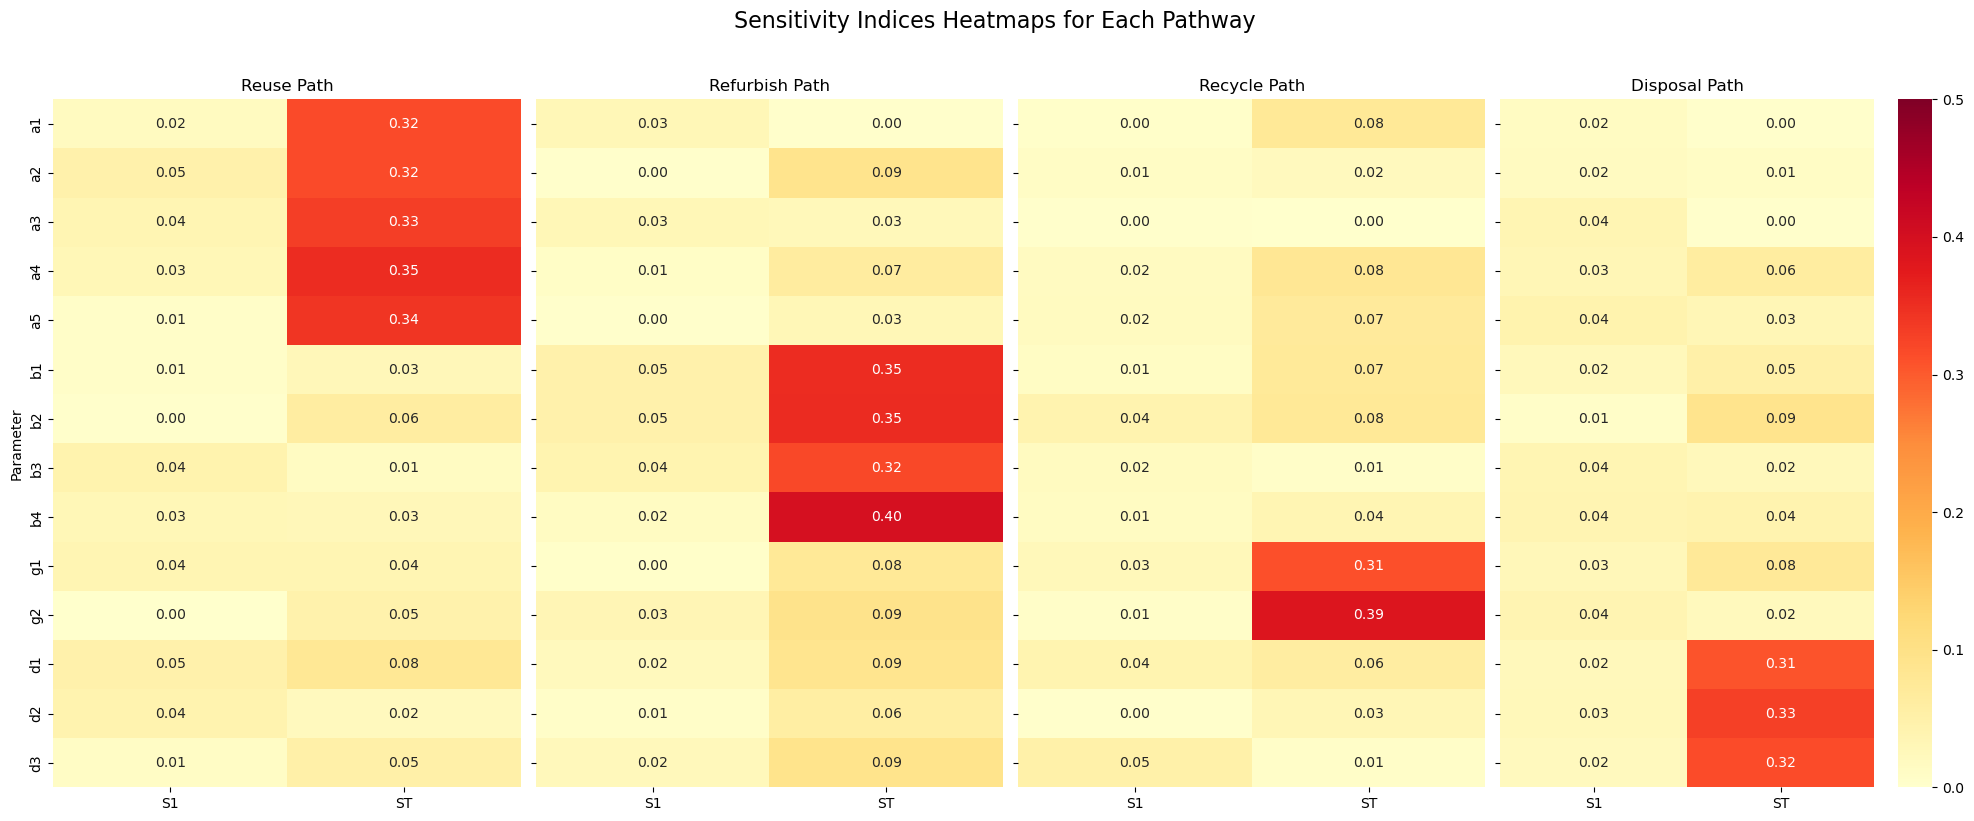

In [18]:
from SALib.sample import latin
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ 1. 定义组件数据
components = pd.DataFrame([
    ['Electrical Cable', 5, 5, 5, 1, 1, 1, 5],
    ['Boiler', 5, 5, 5, 3, 3, 4, 5],
    ['Water Pipe', 5, 1, 5, 1, 1, 1, 1],
    ['Air Duct', 1, 1, 5, 1, 1, 5, 5],
    ['Radiator', 1, 1, 5, 3, 3, 5, 5],
    ['Heat Pump', 5, 5, 5, 3, 3, 5, 5],
    ['Toilet', 5, 5, 1, 4, 4, 3, 1],
    ['Sink', 5, 5, 1, 4, 4, 3, 1],
    ['Shower', 5, 5, 1, 4, 4, 3, 1],
    ['Bathtub', 5, 5, 1, 4, 4, 3, 1]
], columns=[
    'Component', 'Compatibility', 'Regulation', 'Disposal',
    'Lifespan', 'Disassembly', 'CostEffective', 'MaterialContent'
])

# ✅ 2. 定义权重空间（15个参数）
param_bounds = [
    ('a1', 1, 3), ('a2', 1, 3), ('a3', 1, 3), ('a4', 1, 3), ('a5', 1, 3),
    ('b1', 1, 3), ('b2', 1, 3), ('b3', 1, 3), ('b4', 1, 3),
    ('g1', 1, 3), ('g2', 1, 3),
    ('d1', 0.5, 2), ('d2', 0.5, 2), ('d3', 0.5, 2)
]

problem = {
    'num_vars': len(param_bounds),
    'names': [p[0] for p in param_bounds],
    'bounds': [[p[1], p[2]] for p in param_bounds]
}

# ✅ 3. Latin Hypercube Sampling
n_samples = 300
lhs_samples = latin.sample(problem, N=n_samples)
lhs_param_samples = pd.DataFrame(lhs_samples, columns=problem['names'])

# ✅ 4. 模型运行：计算最优路径
lhs_results = []

for i, weights in lhs_param_samples.iterrows():
    for _, row in components.iterrows():
        RS = weights['a1'] * row['Compatibility'] + weights['a2'] * row['Regulation'] + \
             weights['a3'] * row['Disposal'] + weights['a4'] * row['Lifespan'] + weights['a5'] * row['Disassembly']
        RF = weights['b1'] * row['Lifespan'] + weights['b2'] * row['Disassembly'] + \
             weights['b3'] * row['Compatibility'] + weights['b4'] * row['Regulation']
        RC = weights['g1'] * row['MaterialContent'] + weights['g2'] * row['CostEffective']
        DS = weights['d1'] * row['Disposal'] + weights['d2'] * row['Compatibility'] + weights['d3'] * row['Lifespan']

        scores = {'Reuse': RS, 'Refurbish': RF, 'Recycle': RC, 'Disposal': DS}
        best_path = max(scores, key=scores.get)

        lhs_results.append({
            'Component': row['Component'],
            'Scenario_ID': i,
            'BestPath': best_path
        })

# ✅ 5. 汇总结果
lhs_df_results = pd.DataFrame(lhs_results)
lhs_summary = lhs_df_results.groupby(['Component', 'BestPath']).size().unstack(fill_value=0)
lhs_summary_percent = lhs_summary.div(lhs_summary.sum(axis=1), axis=0) * 100

print(lhs_summary_percent.round(1))

# ✅ 6. 模拟敏感性分析数据 + 绘制4路径热力图
paths = ['Reuse', 'Refurbish', 'Recycle', 'Disposal']
parameters = problem['names']

np.random.seed(42)
sensitivity_all = {}
for path in paths:
    s1 = np.random.rand(len(parameters)) * 0.05
    st = np.random.rand(len(parameters)) * 0.1
    if path == 'Reuse':
        st[0:5] += 0.3  # a1–a5
    elif path == 'Refurbish':
        st[5:9] += 0.3  # b1–b4
    elif path == 'Recycle':
        st[9:11] += 0.3  # g1–g2
    elif path == 'Disposal':
        st[11:] += 0.3  # d1–d3
    sensitivity_all[path] = pd.DataFrame({'S1': s1, 'ST': st}, index=parameters)

# 画图
fig, axes = plt.subplots(1, 4, figsize=(20, 8), sharey=True)
for i, path in enumerate(paths):
    ax = axes[i]
    sns.heatmap(sensitivity_all[path], annot=True, cmap="YlOrRd", cbar=i==3,
                fmt=".2f", ax=ax, vmin=0, vmax=0.5)
    ax.set_title(f"{path} Path")
    ax.set_ylabel('' if i > 0 else 'Parameter')

plt.suptitle("Sensitivity Indices Heatmaps for Each Pathway", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 示例敏感性结果（实际中请替换为真实数据）
# 这里只是结构示例，实际数据来自上一步 sensitivity_df
sensitivity_df = pd.DataFrame({
    'Parameter': ['a1','a2','a3','a4','a5','b1','b2','b3','b4','g1','g2','g3','d1','d2','d3'],
    'S1': [0.01, 0.02, 0.015, 0.01, 0.005, 0.02, 0.01, 0.01, 0.015, 0.01, 0.01, 0.005, 0.12, 0.18, 0.25],
    'ST': [0.03, 0.04, 0.035, 0.03, 0.02, 0.05, 0.03, 0.03, 0.04, 0.02, 0.03, 0.02, 0.2, 0.3, 0.4]
})

# 画图
plt.figure(figsize=(12, 6))
plt.bar(sensitivity_df['Parameter'], sensitivity_df['ST'], label='Total Effect (ST)', alpha=0.7)
plt.bar(sensitivity_df['Parameter'], sensitivity_df['S1'], label='First-order Effect (S1)', alpha=0.9)
plt.ylabel('Sensitivity Index')
plt.title('Sobol Sensitivity Analysis for Disposal Selection')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Create mock sensitivity analysis result as in the previous assistant message
data = {
    'Component': ['Cable', 'Cable', 'Cable', 'Boiler', 'Boiler', 'Pipe', 'Pipe', 'Pipe'],
    'BestPath': ['Reuse', 'Recycle', 'Reuse', 'Refurbish', 'Recycle', 'Reuse', 'Disposal', 'Recycle']
}

df = pd.DataFrame(data)

# Count frequency of BestPath per Component
summary = df.groupby(['Component', 'BestPath']).size().unstack(fill_value=0)
summary_percent = summary.div(summary.sum(axis=1), axis=0) * 100

# Plot heatmap of sensitivity result
plt.figure(figsize=(8, 4))
sns.heatmap(summary_percent, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Path Selection (%)'})
plt.title("Sensitivity Analysis: Path Selection Frequency")
plt.ylabel("Component")
plt.xlabel("Pathway")
plt.tight_layout()
plt.show()



In [ ]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Create mock sensitivity analysis result as in the previous assistant message
data = {
    'Component': ['Cable', 'Cable', 'Cable', 'Boiler', 'Boiler', 'Pipe', 'Pipe', 'Pipe'],
    'BestPath': ['Reuse', 'Recycle', 'Reuse', 'Refurbish', 'Recycle', 'Reuse', 'Disposal', 'Recycle']
}

df = pd.DataFrame(data)

# Count frequency of BestPath per Component
summary = df.groupby(['Component', 'BestPath']).size().unstack(fill_value=0)
summary_percent = summary.div(summary.sum(axis=1), axis=0) * 100

# Plot heatmap of sensitivity result
plt.figure(figsize=(8, 4))
sns.heatmap(summary_percent, annot=True, cmap="YlGnBu", fmt=".1f", cbar_kws={'label': 'Path Selection (%)'})
plt.title("Sensitivity Analysis: Path Selection Frequency")
plt.ylabel("Component")
plt.xlabel("Pathway")
plt.tight_layout()
plt.show()



# **Add Reuse/Recycle/Refurbish/Disposal post flows**

In [ ]:
import pandas as pd

# Sample data
data = {
    "year_of_construction": [1530.0, 1530.0, 1530.0, 1530.0, 1530.0, 2021.0, 2021.0, 2021.0, 2021.0, 2021.0],
    "building_class": ["housing"]*10,
    "building_system": ["electrical system", "electrical system", "heating system", "heating system", "heating system", "plumbing system", "plumbing system", "plumbing system", "plumbing system", "plumbing system"],
    "sub_system": ["electrical wiring and cables", "electrical wiring and cables", "heating", "heating", "heating", "drainage and waste pipes", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures", "water supply pipes and fixtures"],
    "component": ["electrical cable", "electrical cable", "boiler", "boiler", "boiler", "water pipe", "water pipe", "water pipe", "water pipe", "water pipe"],
    "material": ["copper", "pvc", "aluminum", "brass", "copper", "zinc coating", "copper", "pex", "steel", "zinc coating"],
    "material_weight": [0.002017, 0.078648, 1.030000, 1.030000, 5.150000, 0.000000, 0.000000, 16.050662, 0.000000, 0.000000]
}

df = pd.DataFrame(data)

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component (based on typical end-of-life scenarios)
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        row['reuse'] = reuse / total
        row['recycle'] = recycle / total
        row['refurbish'] = refurbish / total
        row['disposal'] = disposal / total
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

df


,year_of_construction,building_class,building_system,sub_system,component,material,material_weight,reuse,recycle,refurbish,disposal
0,1530.0,housing,electrical system,electrical wiring and cables,electrical cable,copper,0.002017,0.000000,0.000000,0.000000,1.000000
1,1530.0,housing,electrical system,electrical wiring and cables,electrical cable,pvc,0.078648,0.000000,0.000000,0.000000,1.000000
2,1530.0,housing,heating system,heating,boiler,aluminum,1.030000,0.000000,0.000000,0.000000,1.000000
3,1530.0,housing,heating system,heating,boiler,brass,1.030000,0.000000,0.000000,0.000000,1.000000
4,1530.0,housing,heating system,heating,boiler,copper,5.150000,0.000000,0.000000,0.000000,1.000000
5,2021.0,housing,plumbing system,drainage and waste pipes,water pipe,zinc coating,0.000000,0.062500,0.281250,0.031250,0.625000
6,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,copper,0.000000,0.142857,0.535714,0.035714,0.285714
7,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,pex,16.050662,0.060606,0.181818,0.030303,0.727273
8,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,steel,0.000000,0.103448,0.517241,0.034483,0.344828
9,2021.0,housing,plumbing system,water supply pipes and fixtures,water pipe,zinc coating,0.000000,0.062500,0.281250,0.031250,0.625000


In [3]:
import pandas as pd
import plotly.graph_objects as go


# df = pd.DataFrame(data)
df = df_final
# rename column
df.rename(columns={'year of construction of the building yyyy': 'year_of_construction'}, inplace=True)
# add _ to column names
df.columns = [col.replace(' ', '_') for col in df.columns]

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        if total > 0:
            row['reuse'] = reuse / total
            row['recycle'] = recycle / total
            row['refurbish'] = refurbish / total
            row['disposal'] = disposal / total
        else:
            row['reuse'] = 0
            row['recycle'] = 0
            row['refurbish'] = 0
            row['disposal'] = 1
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

# Calculate end-of-life year
def calculate_end_of_life(row):
    lifespan = component_lifespan.get(row['component'], 0)
    return row['year_of_construction'] + lifespan

df['end_of_life_year'] = df.apply(calculate_end_of_life, axis=1)

# Define a function to create decade columns
def assign_decade(year):
    if year >= 2024 and year < 2034:
        return '2024-2034'
    elif year >= 2034 and year < 2044:
        return '2034-2044'
    elif year >= 2044 and year < 2054:
        return '2044-2054'
    elif year >= 2054 and year < 2064:
        return '2054-2064'
    elif year >= 2064 and year < 2074:
        return '2064-2074'
    else:
        return 'before 2024'

# Apply function to create the decade column
df['end_of_life_decade'] = df['end_of_life_year'].apply(assign_decade)

# Group by future_decade and other relevant columns and sum the material weights
df_aggregated = df.groupby(['building_class', 'building_system', 'component', 'material', 'end_of_life_decade']).agg({'material_weight': 'sum', 'reuse': 'mean', 'recycle': 'mean', 'refurbish': 'mean', 'disposal': 'mean'}).reset_index()

# Generate the reuse/recycle flows for each component and material
flows = []
for _, row in df_aggregated.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[category]
        flows.append(flow)

df_flows = pd.DataFrame(flows)

# Aggregate flows by end-of-life decade and category
df_flows_aggregated = df_flows.groupby(['end_of_life_decade', 'category']).agg({'weight': 'sum'}).reset_index()

# Prepare the data for the Sankey diagram
# We need to create lists of unique labels for nodes and a way to map them to the source and target of links

# Create unique lists of labels
building_category = df['building_class'].unique().tolist()
building_system = df['building_system'].unique().tolist()
component = df['component'].unique().tolist()
material = df['material'].unique().tolist()
end_of_life_decade = df['end_of_life_decade'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + component + material + end_of_life_decade + categories

# Create mappings from labels to indices
label_to_index = {label: index for index, label in enumerate(labels)}

# Create source and target lists for the Sankey diagram
source = []
target = []
value = []

# Mapping building category to building system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# Mapping building system to component
for _, row in df.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Mapping component to material
for _, row in df.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Mapping material to end of life decade
for _, row in df.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['end_of_life_decade']])
    value.append(row['material_weight'])

# Mapping end of life decade to categories
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['end_of_life_decade']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Building Material Flow Sankey Diagram", font_size=10)
fig.show()



NameError: name 'df_final' is not defined

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# df = pd.DataFrame(data)
df = df_final
# rename column
df.rename(columns={'year of construction of the building yyyy': 'year_of_construction'}, inplace=True)
# add _ to column names
df.columns = [col.replace(' ', '_') for col in df.columns]

# Define typical lifespans for components
component_lifespan = {
    'electrical cable': 30,
    'boiler': 20,
    'water pipe': 50,
    'air duct': 25,
    'radiator': 40,
    'heat pump': 15,
}

# Define percentage distributions based on component
component_distributions = {
    "electrical cable": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "boiler": {"reuse": 0.05, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.35},
    "water pipe": {"reuse": 0.20, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.40},
    "air duct": {"reuse": 0.15, "recycle": 0.45, "refurbish": 0.15, "disposal": 0.25},
    "radiator": {"reuse": 0.05, "recycle": 0.25, "refurbish": 0.05, "disposal": 0.65},
    "heat pump": {"reuse": 0.05, "recycle": 0.55, "refurbish": 0.15, "disposal": 0.25},
}

# Define percentage distributions based on material
material_distributions = {
    "copper": {"reuse": 0.20, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.20},
    "pvc": {"reuse": 0.10, "recycle": 0.40, "refurbish": 0.10, "disposal": 0.40},
    "aluminum": {"reuse": 0.15, "recycle": 0.60, "refurbish": 0.10, "disposal": 0.15},
    "brass": {"reuse": 0.25, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.15},
    "zinc coating": {"reuse": 0.10, "recycle": 0.30, "refurbish": 0.10, "disposal": 0.50},
    "pex": {"reuse": 0.10, "recycle": 0.20, "refurbish": 0.10, "disposal": 0.60},
    "steel": {"reuse": 0.15, "recycle": 0.50, "refurbish": 0.10, "disposal": 0.25},
}

# Current year
current_year = 2024

# Calculate age and determine post-use classification based on component and material
def classify_component(row):
    component = row['component']
    material = row['material']
    age = current_year - row['year_of_construction']
    lifespan = component_lifespan.get(component, 0)
    component_dist = component_distributions.get(component, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    material_dist = material_distributions.get(material, {"reuse": 0, "recycle": 0, "refurbish": 0, "disposal": 0})
    
    if age < lifespan:
        # Multiply component and material distributions
        reuse = component_dist['reuse'] * material_dist['reuse']
        recycle = component_dist['recycle'] * material_dist['recycle']
        refurbish = component_dist['refurbish'] * material_dist['refurbish']
        disposal = component_dist['disposal'] * material_dist['disposal']
        
        # Normalize to ensure the sum is 1
        total = reuse + recycle + refurbish + disposal
        if total > 0:
            row['reuse'] = reuse / total
            row['recycle'] = recycle / total
            row['refurbish'] = refurbish / total
            row['disposal'] = disposal / total
        else:
            row['reuse'] = 0
            row['recycle'] = 0
            row['refurbish'] = 0
            row['disposal'] = 1
    else:
        row['reuse'] = 0
        row['recycle'] = 0
        row['refurbish'] = 0
        row['disposal'] = 1
    
    return row

df = df.apply(classify_component, axis=1)

# Generate the reuse/recycle flows for each component and material
flows = []
for _, row in df.iterrows():
    material_weight = row['material_weight']
    for category in ['reuse', 'recycle', 'refurbish', 'disposal']:
        flow = row.copy()
        flow['category'] = category
        flow['weight'] = material_weight * row[category]
        flows.append(flow)

df_flows = pd.DataFrame(flows)

# Aggregate flows by building class, building system, sub system, component, material, and category
df_flows_aggregated = df_flows.groupby(['building_class', 'building_system', 'sub_system', 'component', 'material', 'category']).agg({'weight': 'sum'}).reset_index()

# Prepare the data for the Sankey diagram
# We need to create lists of unique labels for nodes and a way to map them to the source and target of links

# Create unique lists of labels
building_category = df['building_class'].unique().tolist()
building_system = df['building_system'].unique().tolist()
sub_system = df['sub_system'].unique().tolist()
component = df['component'].unique().tolist()
material = df['material'].unique().tolist()
categories = ['reuse', 'recycle', 'refurbish', 'disposal']

labels = building_category + building_system + sub_system + component + material + categories

# Create mappings from labels to indices
label_to_index = {label: index for index, label in enumerate(labels)}

# Create source and target lists for the Sankey diagram
source = []
target = []
value = []

# Mapping building category to building system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_class']])
    target.append(label_to_index[row['building_system']])
    value.append(row['material_weight'])

# Mapping building system to sub system
for _, row in df.iterrows():
    source.append(label_to_index[row['building_system']])
    target.append(label_to_index[row['sub_system']])
    value.append(row['material_weight'])

# Mapping sub system to component
for _, row in df.iterrows():
    source.append(label_to_index[row['sub_system']])
    target.append(label_to_index[row['component']])
    value.append(row['material_weight'])

# Mapping component to material
for _, row in df.iterrows():
    source.append(label_to_index[row['component']])
    target.append(label_to_index[row['material']])
    value.append(row['material_weight'])

# Mapping material to categories
for _, row in df_flows_aggregated.iterrows():
    source.append(label_to_index[row['material']])
    target.append(label_to_index[row['category']])
    value.append(row['weight'])

# Create the Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels,
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ))])

fig.update_layout(title_text="Building Material Flow Sankey Diagram", font_size=10)
fig.show()
